<a href="https://colab.research.google.com/github/ShreyasJV/ml-project/blob/main/Discrete_Market_Models_and_Reinforcement_Learning_Strategies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook covers the following:


1.   We develop the theory of a finite market model based on the ETH Zurich course [ "Introduction to Mathematical Finance"](https://metaphor.ethz.ch/x/2024/fs/401-3888-00L/#:~:text=This%20course%20focuses%20on%20discrete,%2C%20401%2D3913%2D01.). This is a probability space of market trajectories, and we define stochastic processes and filtrations on this space to develop the idea of strategies/portfolios which are predictable stochastic processes $\varphi$. We see when and how arbitrage opportunities arise, and what those strategies look like.

2.   We then write up a simulation of this in python. Use a random number generator with seed to set off a market model which updates according to the probability distribution of the model. Later on, we will explore a market that is not well-described by this model but where we attempt to fit the model to it nonetheless. The result is essentially a time series of asset prices and a risk-free bond account. Visualise this

3. Informed by the theory in section 1 where we theoretically understand what good strategies $\varphi$ are, we build a reinforcement learning algo where the policy $\pi_\theta$ is, obviously, trained on the return of the portfolio. We start of by modelling the policy according to some parameterisation of the strategies as understood from the theory. This means that we are essentially doing statistics. Normally in RL we might run the game many times, but here we have one market evolving for time $T$, and we might view this as $N$-many runs of a game of length $T/N$. Since the market model is unchanging, we might hope that the strategy ends up being well clever. We plot the strategy parameters as a function of time, alongside plotting the market as a function of time, and the value of the portfolio. Can our RL algo detect and take advantage of arbitrage? Arbitrage opportunities exist for certain market model parameters (stock increase probabilities and interest rate values).

4. We then imagine that we don't know what a good model for the policy is, and build a neural network with parameters $\theta$. This is statistics for idiots, where we as market observers aren't smart enough to figure out what underlying model is describing what's going on. We see if this larger parameter space still converges by gradient descent to an optimal strategy.

5. Take the $Δt \to 0$ limit and see what everything looks like. We should observe the emergence of structures in stochastic calculus.

6. After all this works, we generalise our model by introducing slowly time-varying parameters in the probability distribution. For example, in the binomial model, the probability of an asset increasing in price at time $t$ becomes $p(t)$ which we can play around with. Repeat the above steps. The reinforcement learning is going to become interesting.




# 1. Finite Market Model Simulations

These are essentially a retelling of [these](https://user.math.uzh.ch/chhaibi/teaching/2014/finance/Finance_notes.pdf) excellent notes for the ETH course. Maybe I'll throw in some interesting computations and proofs along the way. Physicist's arrogance will hopefully take us a long way.

## 1.1. The Binomial (CRR) Model

We model a primary market (i.e. not a secondary market which trades options or other derivatives) with two assets: a risky stock with spot $S_t$ and a riskless bond $B_t=(1+r)^t$ which compounds at interest rate $r$. The histories up to time $T$ are captured by a probability space
$$
(\Omega,\mathcal{F},\mathbb{P})
$$
where $\omega = (\omega_{1},...,\omega_T) \in \Omega$ is a possible market history with discrete time. We can in principle include as much information as we want when specifying $\Omega$, but the important data for our purposes is captured by the random variables
$$
\xi_t:\Omega \to \mathbb{R}
$$
which describes the price change of the stock at time $t$. This means the spot of the stock is a product random variable
$$
S_t = S_0 \prod_{i=1}^t \xi_t
$$
where $S_0$ is the initial price. The model assumes that $\xi_t$ are Bernoulli random variables, which means we do a coin flip at each time for whether the stock goes up or down. This means that $\xi_t$ has two outputs $u$, $d$ which are multiplicative factors where $u >1$ and $0<d<1$. The probability of going down at a given time is given by
$$
\forall t \in \{1,..,T\}: \mathbb{P}(\xi_t=d) = p = 1-\mathbb{P}(\xi_t=u).
$$
We therefore have a one-parameter model specified by $p \in [0,1]$. Our reinforcement learning agents will hopefully recognise that this is a good model of the behaviour and zero in on this parameter... The measure $\mathbb{P}$ is the historical probability, which is a weird name for actual probability, and is meant to be in contrast with other measures like the risk-neutral measure which will be useful for theoretical calculations later like for solving pricing problems etc.

For concreteness, we will set $\Omega:= \{u,d\}^{\times T} = \{(\omega_1,...,\omega_T) | \omega_i \in \{u,d \} \}$, and choose the event space to be the power set (when do we not do this tbh). Then the random variables act as $\xi_t(\omega)=\omega_t$ and the measure is
$$
\mathbb{P}( \{\omega \}) = \prod_{i=1}^T \mathbb{P}(\xi_i(\omega)).
$$
This defines our model.

We will implement this as a function

    def market_traj(S0,B0,u,d,T,n,p,r,seed=None):
      
      """
      S0 = initial stock price
      B0 = initial bond price
      u = rise factor for stock
      d = dip factor for stock
      T = total time interval in some units
      n = dimensionless number of time steps
      p = probability to go down
      r = bond interest rate (deterministic)
      seed = random number seed for reproducibility of results, none by default which gives generic random number
      
      """

      time interval dt = T/n
      
      #want n Bernoulli draws, which are binary outcomes with P(1)=p
      
      draw n uniformly distributed random numbers in (0,1) into a list L
      construct list of booleans Boo=(L < p). Will have approx p*N trues and (1-p)*N falses.
    
      #want to build a list of cumulative multiplications of u and d acting on S0 according to the list Boo.

      multiply trues in Boo by d and falses in Boo by up. gives a list called F for factors.
      construct a list of cumulative products, C={F[0],F[0]*F[1],F[0]*F[1]*F[2],... } with n entries

      for each m<n, we note the stock price at m*T/n as C[m]*S0. build a list S={S0,S1,S2,...,ST}

      build alongside it a timeline = {0,T/n,2*T/n,...,T} so we can plot stuff

      #finally, construct a list of bond prices
      
      bonds = [B0*(1+r)^x for x in timeline]

      #return outputs

      return timeline, stockprices, bondprices



Let's build this and plot some market trajectories for different seeds below

      

      




In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200


def market_traj(S0,B0, u, d, T, n, p, r, seed=None):
  """
  Sample an asset price trajectory that has dynamics described by the binomial CRR model.

  Params:
  S0: float - initial stock price
  B0: float - initial bond price
  u: float - stock increase factor
  d: float - stock decrease factor
  T: float - trajectory time interval in some choice of units
  n: int - number of time steps
  p: float - probability of stock going down
  r: float - deterministic interest rate for bond
  seed: int - optional RNG seed for reproducibility


  Returns:
  timeline  : np.ndarray, shape (n+1,) - time grid [0, Δt, 2Δt, ..., T]
  stockprice : np.ndarray, shape (n+1,) - sampled price path [S0, S1, ... , ST]
  bondprice : np.ndarray, shape (n+1,) - sampled price path [B0, B1, ... , BT]
  """
  rng = np.random.default_rng(seed) # this is a random number generator which we will use to generate lists below

  deltat = T/n

  # we compute n Bernoulli draws and turn them into a list of multiplications to perform

  downmoves = rng.random(n) < p #rng.random(n) is a list (shape is (n,)) of n random numbers uniform in (0,1), then we get a list of n booleans. approx p*n trues and (1-p)*n falses.
  factors = np.where(downmoves, d, u) #if downmoves[i]=1, multiply it by the factor d, else multiply it by u. this is shape (n,)

  # we build a list of cumulutative products to act on the stock price with, giving our list of stockprices
  timeline  = np.linspace(0, T, n + 1)
  stockprices = S0 * np.concatenate([[1.0],np.cumprod(factors)]) #cumprod(factors) is a cumulutative mult of factors, giving a list of n numbers. we append 1.0 as the new first element, then multiply the whole list by S0 to get S0,S1,...

  #we build our bond price list
  #bondprices = [B0*(1+r)**t for t in timeline]
  bondprices = B0 * (1+r) ** timeline #neater than above commented out line, and makes it output as an np.array whereas the above doesn't.


  return timeline, stockprices, bondprices


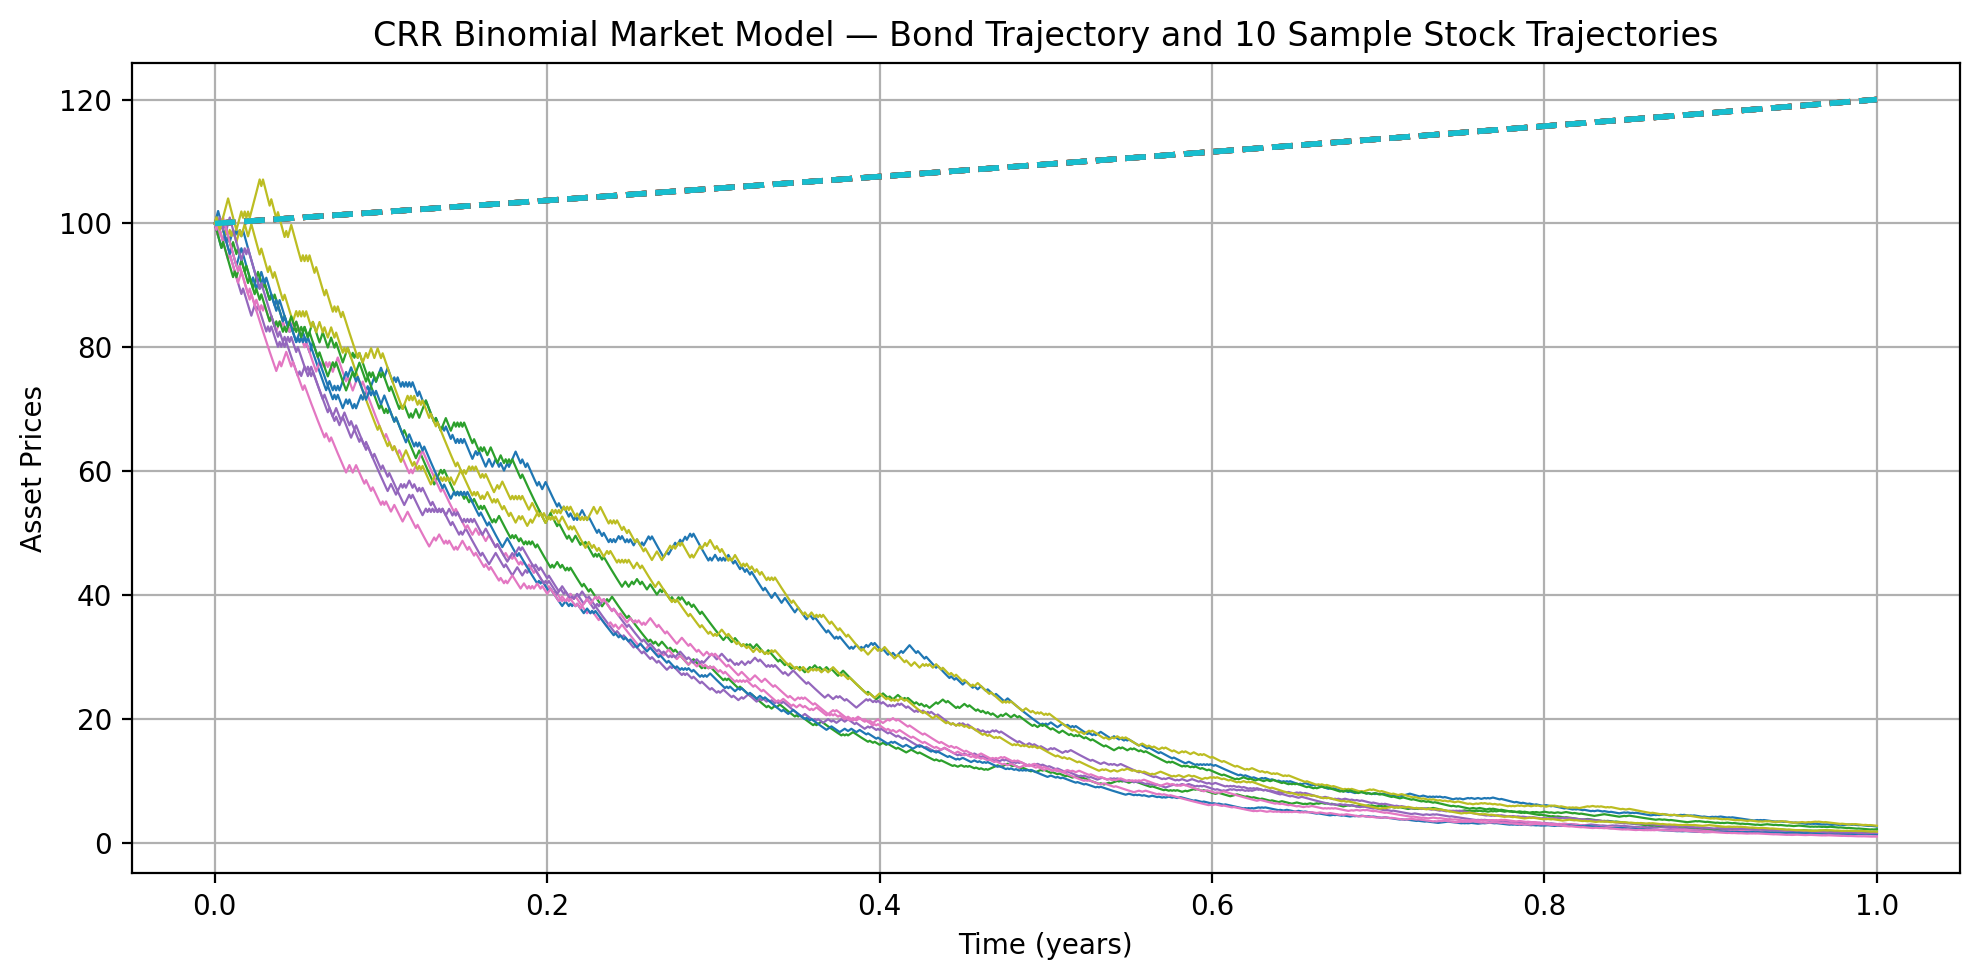

In [ ]:
# @title
fig, ax = plt.subplots(figsize=(10, 5))

numseeds = 10
for i in range(numseeds): #a bunch of seeds
    times, stockprices, bondprices = market_traj(S0=100,B0=100 , u=1.01, d=0.99, T=1, n=1000, p=0.7,r=0.2, seed=i)
    ax.plot(times, stockprices, alpha=1, linewidth=0.8)
    ax.plot(times, bondprices, alpha=1,linestyle='--',linewidth=2)

ax.set_xlabel("Time (years)")
ax.set_ylabel("Asset Prices")
ax.set_title(f"CRR Binomial Market Model — Bond Trajectory and {numseeds} Sample Stock Trajectories")
ax.grid(True)
plt.tight_layout()
plt.show()

Now that we have a market model, let's start building strategies. One interesting goal is to see what good and bad strategies look like, particularly when there are arbitrage opportunities. Later in this notebook, I want to train an agent to recognise and capitalise on arbitrage.

The definition of a strategy is a predictable stochastic process. this means:

- We build a filtration $\mathbb{F} = (\mathcal{F}_t)_{0 \leq t \leq T}$ of increasing $\sigma$-subalgebras (event spaces). In particular, we choose $\mathcal{F}_t$ to be the smallest $\sigma$-algebra that makes the random variables $\xi_1,...\xi_t$ measurable, that is, $\xi^{-1}_{1,...,t}(U \subset \mathbb{R})$ is an event in $\mathcal{F}_t$. We will be building conditional probabilities with respect to these events which capture "what happens up to time t". It is a theorem that all measurable functions on $\mathcal{F}_t$ i.e. random variables on it, are functions of the $(\xi_1,...,\xi_t)$.  This is completely obvious intuitively.

- We then build a stochastic process $\varphi = (\varphi_t)_{0 \leq t \leq T}$ which is *predictable*, meaning that all $\varphi_t$ are measurable with respect to $\mathcal{F}_{t-1}$. Physically, this means that given the knowledge of the dynamics up $[0,t-1]$, there is a well-defined strategy move $\varphi_t$ that is made during the interval $(t-1,t)$. Overall, it is a random variable because the market is random.

- To have a *strategy*, we take the above predictable stochastic process and ask that $\varphi_t: \Omega \to \mathbb{R}^2$ have output $(\alpha_t,\beta_t)$ where $\alpha_t$ is the number of shares to hold during $(t-1,t]$ and $\beta_t$ is the number of bonds to hold during $(t-1,t]$. $\alpha_t<0$ means that we are short-selling the stock, i.e. we are borrowing stock without paying for it and are in debt to pay it back. This will be useful if we think the stock will dip in price later, but is valuable now (borrow 1 share now, use it to buy bonds, wait, then pay debt later using bond interest by buying 1 share at cheap). $\beta_t<0$ means that we borrow money from the bank. Predictibability means that the strategy is well defined given the known market history at time $t$, and we rebalance the portfolio (buy and sell shit) during the breathing time $[t-1,t)$.

Now that we have a strategy, we need a way of studying its properties so that we can say if it is good or bad and what it can do for us. An obvious measure of goodness is the value of the portfolio as a function of time:
$$
\forall t \in \{0,...,T\}: V_t(\varphi) = \alpha_t S_t + \beta_t B_t.
$$
This is obvious. We want to impose a self-financing condition, that during the interval $(t,t+1)$ we can only rebalance the portfolio with the fixed amount of money given by $V_{t}(\varphi)$. This means $V_t(\varphi) = \alpha_{t+1}S_t + \beta_{t+1} B_t$. Just writing this all out:
$$
\forall t \in \{0,...,T \}: \alpha_t S_t + \beta_t B_t = \alpha_{t+1} S_t + \beta_{t+1} B_t
$$
which is a constraint on the parameters of the strategy, called the self-financing constraint.

I mentioned that we would like to identify arbitrage in this market. Importantly, this is a primary market so there are no complications given by option trading... we will get to secondary markets once we are strong with the primary market here. Within this model, an arbitrage is a self-financing strategy $\varphi$ such that

- There is no initial cost $V_0(\varphi)=0$. The self-financing constraint means that we must start out by borrowing stocks and/or bonds.

- $\mathbb{P}[V_T(\varphi) \geq 0] = 1$

-  $\mathbb{P}[V_T(\varphi) > 0] > 0$ i.e. the previous bulletpoint does not collect all the probability around $V_T=0$.

A theorem that we can prove using pricing theory is that the model is arbitrage-free if and only if $d<1+r<u$. This is really an application of the first fundamental theorem of asset pricing. Very cool stuff.

This will inform some of our numerical experiments later. There is a lot of fascinating pricing theory which I will be learning, but I think do not yet have an application for the kind of ML stuff we want to do in this notebook.

Let's now build a function that takes as input a strategy $\varphi$ and a time series $\omega \in \Omega$ and returns the portfolio value as a function of time. Given the initial investments $\alpha_0,\beta_0$, self financing means that we only need to specify $\alpha_t$ and the initial $\beta_0$ because the $\beta_t$ are determined as
$$
\beta_t = (\alpha_{t-1}-\alpha_t) \frac{S_{t-1}}{B_{t-1}} + \beta_{t-1} = (\alpha_{t-1}-\alpha_t) \frac{S_{t-1}}{B_{0}}(1+r)^{-t} + \beta_{t-1}.
$$
The function will look like the following:

    def strategy_run(timeline, stockprices, bondprices, alpha0, beta0, alphaset)
      """
      parameters:
      timeline: np.ndarray shape (n,) - discrete times from 0 to T
      stockprices: np.ndarray shape (n,) - sampled stockprices as a function of time
      bondprices: np.ndarray shape(n,) - bondprices as a function of time
      (the above will be taken as outputs of market_traj with some parameters chosen)
      alpha0: float - initial stock investment
      beta0: float - initial bond investment
      alphaset: function - a function alphaset(t,stockbond) where the first argument t labels which function we have (ie it's a parameterised family) and the second argument contains the entire list of stocks and bonds in the form [[s0,b0],...,[sT,bT]]. The t'th function only depends on s0b0 ... stbt.
      """

      #first we get the values of the alpha_t and beta_t by computing them at each time step.

      n=size(timeline)
      alphaval[0]=alpha0
      betaval[0]=beta0
      stockbond = zip(stockprices,bondprices) #will look like [[s0,b0],...,[sT,bT]]

      for t in range(1,n): #i.e. we don't want to mess with the initial conditions
        alphaval[t] = alphaset(t,stockbond)
        betaval[t] = betaval[t-1] + (alphaval[t-1] - alphaval[t]) * stockprice[t-1] / bondprice[t-1]

      #then we get a time series of portfolio values by taking alpha_t S_t + beta_t B_t for all t in timeline

      V = [alphaval[t]*stockprice[t] + betaval[t]*bondprice[t] for t in range(n) ]

      return V


I have a technical debt here: how do we efficiently build alphaset? The most bruteforce approach is

    def alphaset(t,stockbond):
      if t==0:
        ...
      elif t==1:
        ...
      .
      .
      .
      elif t==T:
        ...

This is a pain to write down, so we will need to parameterise this somehow. These issues won't really affect us when we build RL agents though. We can play around with

    def alphaset(t,stockbond):
      x=0
      for i in range(size(stockbond)):
        x+= (t<i)*(stockbond[j][0]+stockbond[j][1] for j < i)
    return x

This looks like $\alpha(t) = \sum_{i} \delta(t<i) \sum_{j<i} S_j + B_j$ which does satisfy the predictability constraint. We could generally put whatever we want after the $(t<i)$ term in the code above. That would constitute a general solution.

We will develop this below and then start plotting some example strategies. Then it will get interesting: because we are too stupid to compute a family of good strategy functions, let's model the collection of $\alpha_t$ as a neural network. We can then view $\varphi$ as a policy in the sense of RL, and the return function as the value of the portfolio. We can explore training it in multiple universes vs in one big time series, and just see what happens! I'm basically proposing to mix RL and recurrent neural network architectures to make money.


Out of interest, what is the expected value of the portfolio after time $T$? do this



In [ ]:
# @title
def strategy_run(timeline, stockprices, bondprices, alpha0, beta0, alphaset):

  """
  parameters:
  timeline: np.ndarray shape (n,) - discrete times from 0 to T
  stockprices: np.ndarray shape (n,) - sampled stockprices as a function of time
  bondprices: np.ndarray shape(n,) - bondprices as a function of time
  (the above will be taken as outputs of market_traj with some parameters chosen)
  alpha0: float - initial stock investment
  beta0: float - initial bond investment
  alphaset: np.ndarray shape (n,) - strategy parameters, an array of n FUNCTIONS [alpha_1,...,alpha_T] where alpha_t is a function of stockprice[0],...,stockprice[t] and bondprice[0],...,bondprice[t]. the betaset is then fixed by the self-financing condition, so these alphas are unconstrained!
  """

  timesteps=np.size(timeline)
  alphaval = np.zeros(timesteps)
  alphaval[0]=alpha0 #sets initial condition
  betaval = np.zeros(timesteps)
  betaval[0]=beta0 #sets initial condition
  stockbondtimeseries = [[stock, bond] for stock, bond in zip(stockprices, bondprices)] # this will output an array [[S0,B0], [S1,B1],...,[ST,BT]]

  for t in range(1,timesteps):
    alphaval[t] = alphaset(t,stockbondtimeseries)
    betaval[t] = betaval[t-1] + (alphaval[t-1] - alphaval[t]) * stockprices[t-1] / bondprices[t-1] #the self-financing condition tells us what our bank account is

  V = [alphaval[t]*stockprices[t] + betaval[t]*bondprices[t] for t in range(timesteps) ]

  return V




We build a completely terrible example below just to see what it looks like

In [ ]:
# @title
def alphasettest(t,SB):
  x=0
  n = int(np.size(SB)/2) # size returns 2*timescale because each time gets a stock and a bond price.
  for i in range(1,n): #alpha0 is an initial condition, we are building our random variables starting from alpha1 hence the range
    x += (t<i)*np.sum( [SB[j][0] + SB[j][1] for j in range(i)] )*(1/n)*np.exp(-10) #when t<i, we form a list [...] as written and then add all its elements, as an example shit strategy
  return x

def randomstrat(t,SB):
  random_investment = np.random.normal() #use loc and scale for mean and std resp.
  return random_investment


def cryptobro(t,SB): #cryptobro strat: buy buy buy!
  return 5

def ilovebonds(t,SB): #we buy no stocks
  return 0


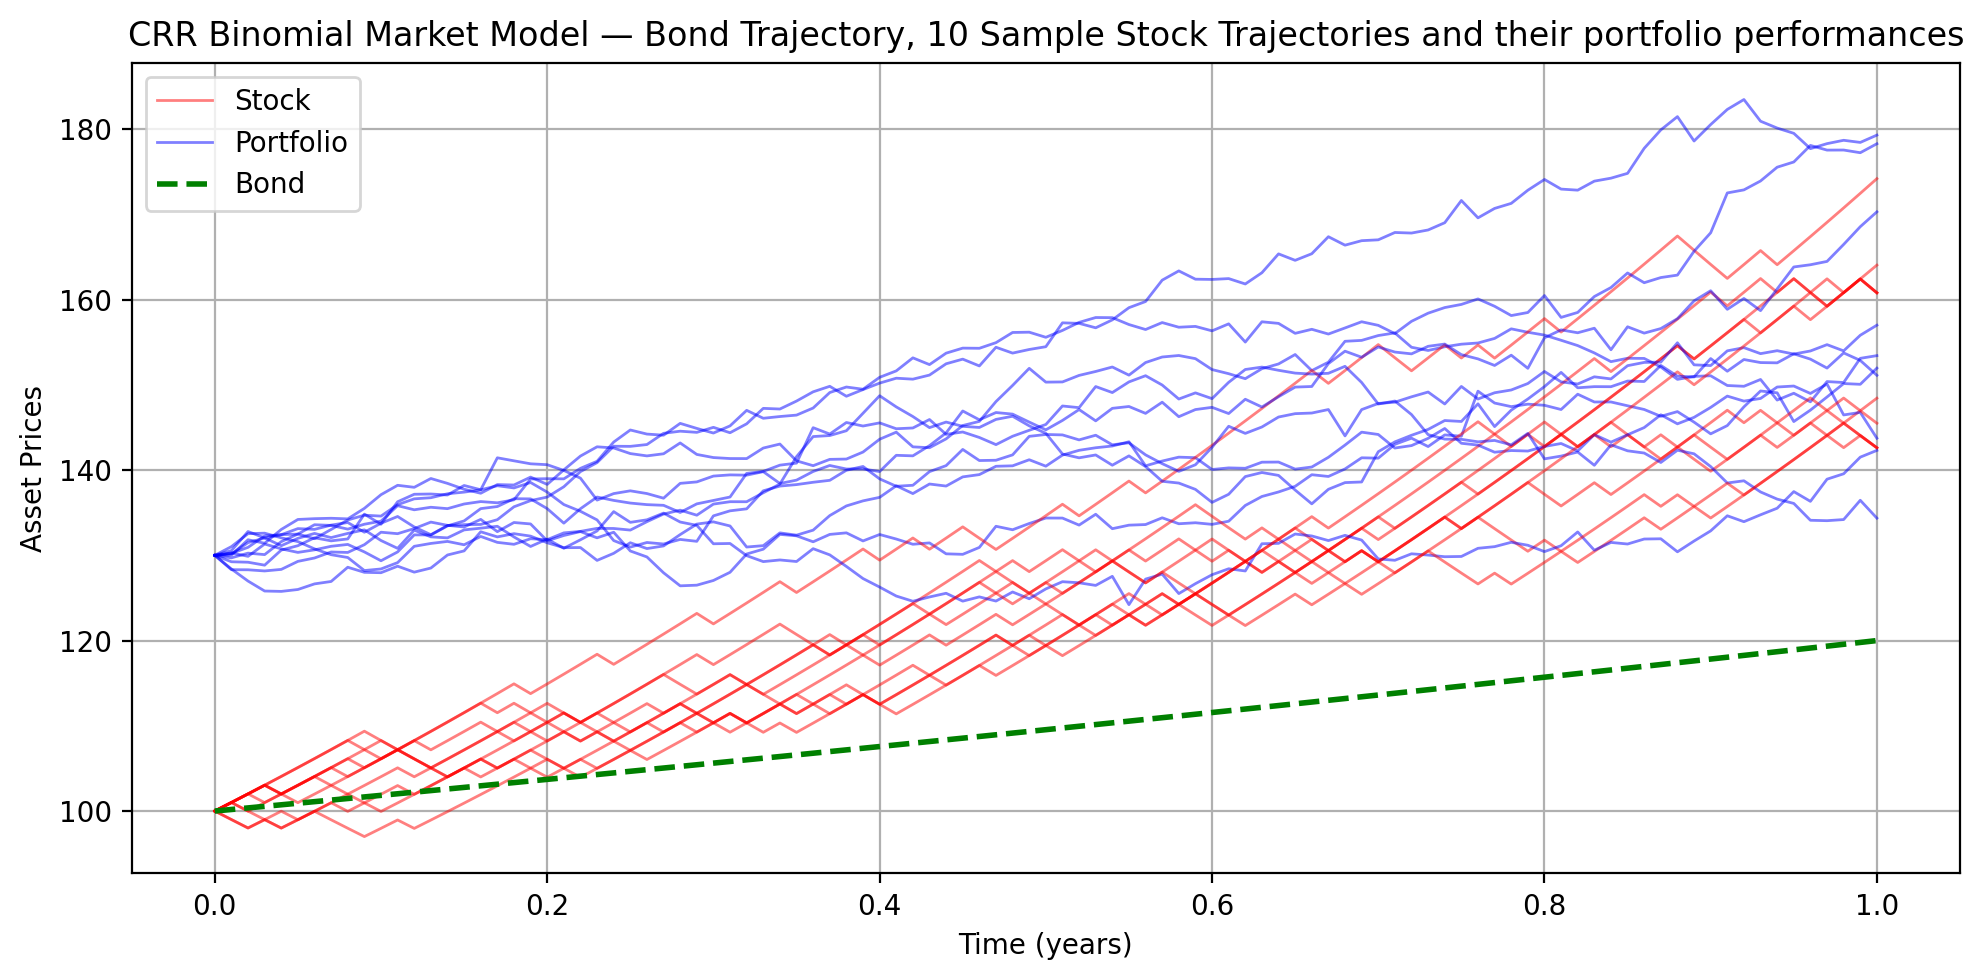

In [ ]:
# @title
fig, ax = plt.subplots(figsize=(10, 5))

numseeds = 10
for i in range(numseeds): #a bunch of seeds
    times, stockprices, bondprices = market_traj(S0=100,B0=100 , u=1.01, d=0.99, T=1, n=100, p=0.3,r=0.2, seed=i)
    portfolio = strategy_run(times,stockprices,bondprices,0,1.3,randomstrat)
    if i==0:
      ax.plot(times, stockprices, alpha=0.5, linewidth=1,color='red',label='Stock')
      ax.plot(times,portfolio,alpha=0.5, linewidth=1,color='blue',label='Portfolio')
    else:
      ax.plot(times, stockprices, alpha=0.5, linewidth=1,color='red')
      ax.plot(times,portfolio,alpha=0.5, linewidth=1,color='blue') #this is in the for-loop because the strategy is a random variable based on the random stock prices

ax.plot(times, bondprices, alpha=1,linestyle='--',linewidth=2,color='green',label='Bond') #the bonds are modelled as deterministic here, so fall outside the loop
ax.legend()


ax.set_xlabel("Time (years)")
ax.set_ylabel("Asset Prices")
ax.set_title(f"CRR Binomial Market Model — Bond Trajectory, {numseeds} Sample Stock Trajectories and their portfolio performances")
ax.grid(True)
plt.tight_layout()
plt.show()

It's obvious that these strategies I pulled out of my ass is extremely risky, but it can actually sometimes make me a profit because the stock can just be that good given the market parameters I chose above. This gives me the motivation to learn about how to quantify the risk of a strategy, which I'm excited to get to.

Can we write a more informed strategy based on some theory? Pricing theory emphasises finding a strategy whose final value is the payoff of an option (the payoff can be viewed as a random variable just like $V_T(\varphi)$), and noting that the initial value of such a portfolio is the fair price of an option. This leads to the discovery of risk-neutral measures and other related tools which are used for pricing and hedging calculations, but for our purposes of just finding clever strategies I'm not yet sure if this helps.. looks like notions such as utility are useful here. Claude says that maximising the expected log-utility leads to a markov strategy in that it depends on the most recent value of the stock prices and the portfolio price (the latter implicitly depends on the price history though). I'll read through the big french superstring guy's book to do this well.

Let's pause on the financial mathematics theory for a bit. We have essentially constructed a game that is ripe for a reinforcement learning agent to play. The environment can be considered trivially Markov in that the stock dynamics do not depend on the stock history or even the stock at the previous time step, but just the global market parameters ($p,u,d,T$). We can start by doing statistics, modelling our policy in some clever way and then optimising. Then, we will become even more general and view the policy function as a neural network with input the state of the system and output a probability distribution of actions to take: $\text{NN}(s_t) \sim \pi_\theta(a_t|s_t)$. We can do a bunch of numerical experiments to figure out how it's learning and see ourselves what good strategies look like: when to borrow, when to buy, etc. I want to do this RNN/RL combo and see how the spread of the policy distribution should eventually shrink as the agent becomes more sure how to play.

## 1.2. Finite Models with Multiple Assets

Let's generalise the above discussion to simulate a market of $d$-many assets whose discrete-time dynamics is controlled by some probability distribution. We also construct strategies and plot their portfolio values with time.

...

# 2. Reinforcement Learning Approaches to Investment Strategies

## 2.1. Policy Gradient

The general theory is that we have an agent interacting with an environment in discrete time, performing actions that change the state of the environment. The agent makes decisions by sampling from a probability distribution
$$
\pi_\theta(a_t|s_t)
$$
that controls the chance of performing action $a_t$ in the time interval $(t,t+1]$ given that the state of the system is $s_t$. Given that the policy is not dependent on the $s_{j<t}$ or $a_{j<t}$, our agent is memoryless (this will be addressed with Q-learning later, I think). This function is called the policy and parameterised by $\theta \in \Theta$. Again, if we are clever enough to do statistics then we might model the policy as a function of $\theta$, but if we don't know at all what a good policy might look like, then we can consider $\pi_\theta$ as a neural network that takes $s_t$ as input and outputs a probability distribution for $a_t$ (outputting normalised distributions suggests that we ought to use a softmax activation by the way). We update our policy parameter $\theta$ by performing gradient descent on $\Theta$ with respect to the expected reward of the game!

As we perform $a_t$ in response to $s_t$, the game rewards us at time $t+1$ with $r_t$ where we observe the new state $a_{t+1}$ of the system. For example, for our market models, we see a stock price and bond price at $t$ as $s_t$, buy three shares of stock in the interval as $a_t$, and then see the market update to a higher stock price. The reward is $r_t = V_{t+1}-V_t$, the change in portfolio value. The total return is
$$
R= \sum_{t=1}^T r_t.
$$
Now, we know the market is described by a probability space $(\Omega,\mathcal{F},\mathbb{P})$. To model our uncertainty about the investor, including in principle how the market responds to the investments, we enlarge our model to the probability space
$$
(\mathfrak{T},\mathcal{E},p_\theta)
$$
where $\mathfrak{T} \ni \tau = (s_1,a_1,s_2,a_2,...,s_T,a_T)$ describes a trajectory of environment states and agent actions (clearly $a_T$ won't really matter much, because we didn't give the environment time to respond!). The probability $p_\theta$ accounts for the $\mathbb{P}$ of the environment as well as the random choice of decision that the agent makes. Clearly, the probability of a trajectory is
$$
p_\theta(\tau) = \prod_{i=1}^T \mathbb{P}(s_{t+1}|a_t,s_t) \cdot \pi_\theta(a_t|s_t)
$$
where in the notation above we define $\mathbb{P}(s_{T+1}|a_T,s_T):=1$ because $s_{T+1}$ doesn't actually exist in $\tau$. That's fine.

This formalism allows for the environment to respond to the agent's actions, which is good for big effectual agents. In our applications below, we will make the simplifying assumption that the investor is so small and meaningless that the market trajectory won't be affected by it at all.

On this $\mathfrak{T}$, the instant and total returns $r_t$ and $R$ are random variables. We want to perform gradient descent in $\Theta$ to maximise $\mathbb{E}_{-}[R] \in C^\infty(\Theta)$ where $\mathbb{E}_{-}[R](\theta):= \mathbb{E}_\theta[R] = \sum_{\tau \in \mathfrak{T}}p_\theta(\tau) R(\tau)$. At first order, the update equation is
$$
\delta \theta^a = + \eta g^{ab} \frac{\partial}{\partial \theta^b} \mathbb{E}_{-}[R] + \mathcal{O}(\eta^2)
$$
where we will probably just have $g_{ab}=\delta_{ab}$, but I keep my mind open. We can just go ahead and take the derivative, but the important practical principle is that the environment is not actually responding to the policy itself, but rather the individual actions in a Markovian way. This makes $\theta$-derivatives easy to take, and we get
$$
\delta \theta^a = + \eta g^{ab} \mathbb{E}_{-}\bigg[ R \cdot \sum_{t=1}^T \frac{\partial}{\partial \theta^b} \log \pi_\theta (a_t|s_t)  \bigg] + \mathcal{O}(\eta^2).
$$
This is beautiful because we can actually numerically approximate this. Here's generally how a RL algo works in a setting where we can play one game numerous times (think poker, chess, etc)



1.  Initialise a policy $\theta_0$
2.  Run a game by sampling the policy at each $t$
3.  Store the states and actions that occured into a sample $\tau_\text{seen} = (s_1,a_1,...,s_T,a_T)$
4.  Compute the return $R(\tau_\text{seen})$
5.  Given that you should draw a likely $\tau$, we know $\mathbb{E}_\theta (X) \approx X(\tau_\text{seen})$ for a random variable $X$. Use this to update $\delta \theta^a = + \eta g^{ab}  R(\tau_\text{seen}) \sum_{t} \frac{\partial}{\partial \theta^b} \log \pi_\theta (a_t|s_t)$ where the $a_t,s_t$ are the ones used in $\tau_\text{seen}$. To compute the derivative of the policy, we of course need to know what our policies are for nearby $\theta$, but that is something we do know.
6.  If we want a stronger approximation to the expected return, we can run many trajectories for a given $\theta$, collect their data, and then use these to get $\mathbb{E}[X] \approx N^{-1} \sum_{\tau} X(\tau)$ where we collect $N$-many $\tau$'s. Note to self: write proofs for this staistics intuition!
7.  Either way, update your $\theta$'s and repeat!

To get some practice with this, let's do some of the exercises from [these](https://scipost.org/SciPostPhysLectNotes.29) notes by Florian Marquardt.

### 2.1.1. Go Go Go!

Let's build a game where the state of the system is the position of the player on $\mathbb{Z}$. We denote this $x_t$. The player can act by moving left or right by one unit $a_t = \pm 1$. The environment is deterministic, so $\mathbb{P}(x_{t+1}|a_t,x_t) = \delta_{x_{t+1}, a_t + x_t}$. The aim of the game is encoded in the return which is simply chosen as $r_t=a_t$, which implies
$$
R(\tau) = \sum_{t=1}^T a_t = x_T.
$$
The optimum strategy is obviously $\pi(a_t|s_t)=\delta_{a_t,1}$. How do we see the RL algorithm converge to this?

Let's model the policy. Since we know it is a normalised probability, it is natural to use the sigmoid. We also impose by hand that the policy does not use feedback, so it is just a function of $a_t$ and not of $s_t$.
$$
\pi_\theta(+1) = \frac{1}{1+e^{-\theta}}, ~\pi_\theta(-1) = 1 - \pi_\theta(+1).
$$
which means the probability is
$$
p_\theta(x_1,a_1,...,x_T,a_t) = \prod_{t=1}^T \delta_{x_{t+1}, a_t + x_t} \pi_\theta(a_t) = \prod_{t=1}^T \pi_\theta(a_t)
$$

where in the second line we used the fact that the trajectory was an allowed trajectory. By restricting to these samples which follow the rules of the game, $\mathbb{P}$ is effectively always one.

Our parameter space is $\Theta = \mathbb{R}$ and we expect the gradient descent to send $\theta \to \infty$. To perform the descent, we evaluate now the log-gradients

\begin{align}
\partial_\theta \log \pi_\theta (+1) &= 1 - \pi_\theta(+1) = \pi_\theta(-1)
\\
\partial_\theta \log \pi_\theta (-1) &= -\pi_\theta(+1)
\end{align}

So the thing that multiplies the return in the gradient descent equation is therefore
$$
\sum_{t=1}^T \partial_\theta \log \pi_\theta (a_t) = N_+ - T \pi_\theta(+1)
$$
where $N_+$ is the number of up-steps in $\tau$. We see that $N_+$ here is a random variable, while $T \pi_\theta(+1)$ is just a constant as far as $\mathfrak{T}$ is concerned. The EV of $N_+$ is
\begin{align}
\mathbb{E}_\theta[N_+] = \sum_{\tau} p_\theta(\tau) N_+(\tau) &= \sum_{a_1,...,a_T \in \{1,-1 \}} \prod_{i=1}^T \pi_\theta(a_i)   \sum_{t=1}^T \delta_{a_t,+1}
\\
&= \sum_{t=1}^T \sum_{a_1,...,a_T \in \{1,-1 \}} \prod_{i=1}^T \pi_\theta(a_i)  \delta_{a_t,+1}
\\
&=\sum_{t=1}^T \sum_{a_1,...,a_T \in \{1,-1 \}} \pi_\theta(a_t) \delta_{a_t,+1} \prod_{s \neq t} \pi_\theta(a_s)
\\
&= \sum_{t=1}^T \pi_\theta(+1) \prod_{s \neq t} \sum_{a_s \in \{+1,-1 \}} \pi_\theta(a_s)
\\
&= \sum_{t=1}^T \pi_\theta(+1) \prod_{s \neq t} 1
\\
&= T \pi_\theta(+1)
\end{align}
which also matches our intuition from frequentist probability. The average number of ups is the probability of a single up times the number of steps. Now the return is
$$
R(\tau)=\sum_t a_t = N_+ - N_- = 2N_+ - T
$$
so we can write the relevant term in our gradient descent formula as
\begin{align}
\delta \theta &= \eta \mathbb{E}_\theta [R \cdot (N_+ - \overline{N}_+)]
\\
&= \eta \mathbb{E}_\theta [(2N_+ - T)(N_+ - \overline{N}_+)]
\\
&= \eta \mathbb{E}_\theta [2N_+ (N_+-\overline{N}_+)] - \eta T \mathbb{E}_\theta[N_+ - \overline{N}_+]
\\
&= 2\eta \mathbb{E}_\theta [N_+ (N_+-\overline{N}_+)]
\\
&= 2 \eta (\mathbb{E}_\theta [N_+^2] - \mathbb{E}_\theta[N_+]^2)
\\
&= 2 \eta \mathbb{E}_\theta [(N_+ - \overline{N}_+)^2 ]
\end{align}
We can compute this variance, since we are just playing around with Bernoulli random variables:
\begin{align}
\mathbb{E}[N_+^2] &= \sum_{a_1,...,a_T \in \mathbb{Z}_2^{\times}} \prod_{i=1}^T \pi_\theta(a_i) \cdot \sum_{t,l=1}^{T} \delta_{a_t,1} \delta_{a_l,1}
\\
&=\sum_{t=1}^T \sum_{l=1}^T \sum_{a_1,...,a_T} \delta_{a_t,1} \delta_{a_l,1} \prod_{i=1}^T \pi_\theta(a_i)
\\
&= \sum_{t=1}^T \pi_\theta(+1) \prod_{i \neq t} \sum_{a_i} \pi_\theta(a_i) + \sum_{t \neq l} \pi_\theta(+1)^2 \prod_{i \neq t,l} \sum_{a_i} \pi_\theta(a_i)
\\
&= \sum_{t=1}^T \pi_\theta(+1) + \sum_{t \neq l} \pi_\theta(+1)^2
\\
&= T\pi_\theta(+1) + (T^2 - T) \pi_\theta(+1)^2
\end{align}
where we split the sum into a $t=l$ part and a $t \neq l$ part. This implies
$$
\text{var}[N_+] = T\pi_\theta(+1) + (T^2 - T) \pi_\theta(+1)^2 - T^2 \pi_\theta(+1)^2 = T \pi_\theta(+1) (1- \pi_\theta(+1))
$$
which is the standard binomial formula (I basically did the $n$ choose $p$ stuff implicitly using the delta functions). Altogether, the gradient descent is
\begin{align}
\delta \theta = 2\eta T \pi_\theta(+1) \pi_\theta(-1) + \mathcal{O}(\eta^2)
\end{align}
which is wonderfully simple. We see that as expected, $\delta \theta \geq 0$ which would drive the policy towards $\pi_{\infty}(+1)=1$, meaning that the agent knows to move in the positive direction. We see that if we initialise on a policy where $\pi_\theta(-1)=1$, then $\delta \theta=0$ and we never get to win the game. This is because the policy distribution is too localised, and doesn't get to explore strategies where it sees that the reward can actually increase! In other words, this policy describes being *confidently stupid*. Viewing $\delta \theta$ as a function of a parameter $\pi_\theta(+1)$, we see that it is a quadratic which positively peaks at $\pi_\theta(+1)=1/2$. This means that step sizes are largest when we start with a very unsure policy. This is good - as we get closer to the best strategy, we update less and less which stops us overshooting for free.

We understand theoretically what will happen now. In parameter space, we have a path described by the differential equation (let real life time be called $\omega$ which is what we update the policy with respect to)
\begin{align}
\dot{\theta} &= 2 T \pi_\theta(+1) \pi_\theta(-1)
\\
&= 2T \frac{e^{-\theta}}{(1+e^{-\theta})^2}.
\end{align}
This is easy to solve:
\begin{align}
&\int \text{d} \theta \frac{(1+e^{-\theta})^2}{e^{-\theta}} = 2T \omega
\\
\stackrel{u=e^{-\theta}}{\iff} &-\int \text{d}u  \frac{(1+u)^2}{u^2} = 2T \omega
\\
\iff & u^{-1} - 2\log(u) - u + C = 2T\omega
\\
\iff & \sinh(\theta) + \theta = T\omega + C.
\end{align}
As $\sinh$ is strictly increasing, this obviously always has solutions. We can write the constant in terms of the initial conditions.
$$
\sinh(\theta) + \theta = T\omega + \sinh(\theta_0) + \theta_0
$$





<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2272/1463955308.py:14: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("real time $\omega$")


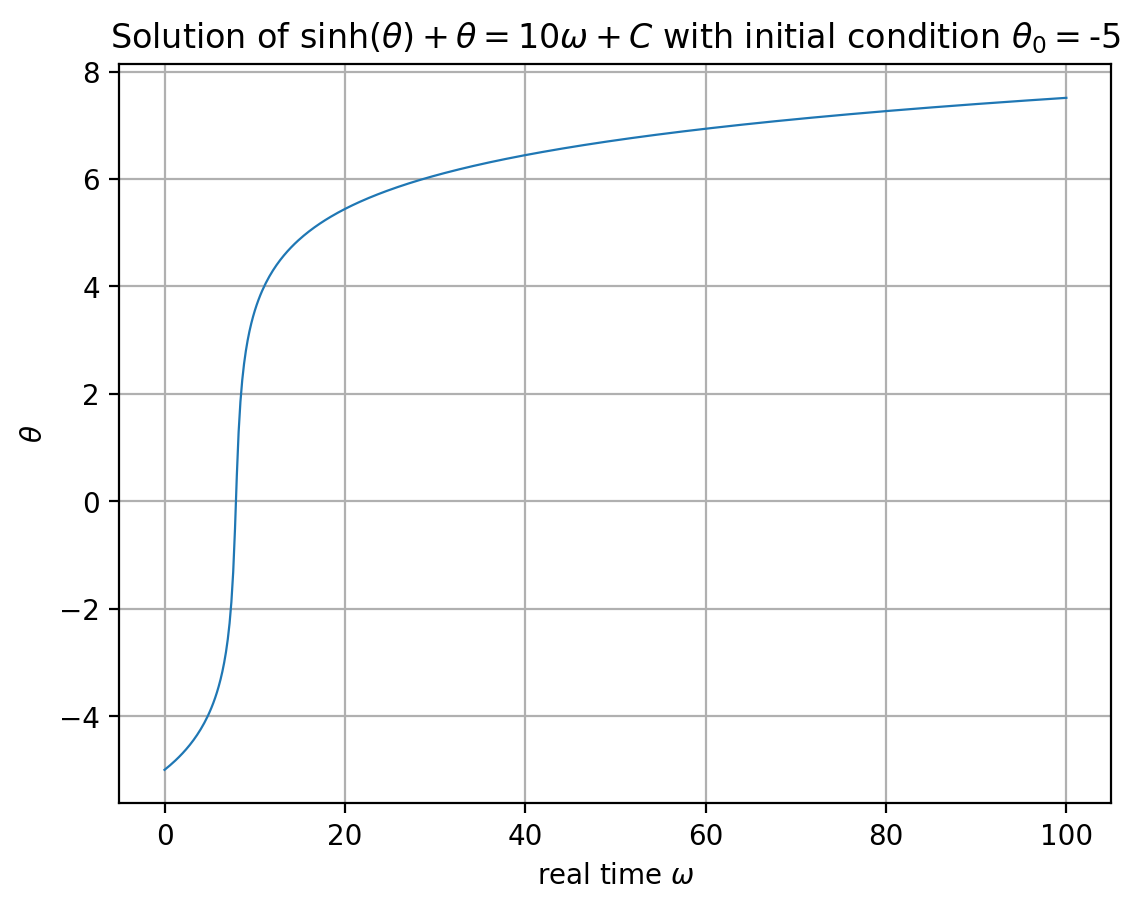

In [ ]:
# @title
from scipy.optimize import brentq

def analytictheta(x, t,T,theta_init):
    c = np.sinh(theta_init) +theta_init
    return np.sinh(x) + x - T*t - c #chose c=0 for integration constant corresponding to IC theta=0

T=10
theta_init=-5
t_vals = np.linspace(0, 100, 500)
x_vals = [brentq(analytictheta, -100, 100, args=(t,T,theta_init)) for t in t_vals] #this is a neat way of solving these implicit equations with analytictheta = 0. was vibe coded.

plt.plot(t_vals, x_vals,linewidth=0.8)
plt.xlabel("real time $\omega$")
plt.ylabel(rf"$\theta$")
plt.title(rf"Solution of $\sinh(\theta) + \theta = {T} \omega + C$ with initial condition $\theta_0=${theta_init}")
plt.grid(True)
plt.show()

So we see exactly how $\theta$ increases as we run the policy gradient algorithm.

Now we want to act like we didn't know this and build an agent that learns by stochastic update. Some theoretical understanding of this: the law of large numbers is the statement that if I have $n$ iid random variables $X_i$ with mean $\mu$ and variance $\sigma^2$, then the average $A_n = \frac{1}{n} \sum_{i=1}^n X_n $ has
$$
\mathbb{P}[\lim_{n \to \infty} A_n = \mu]=1
$$
which means that while $X_i$ are spread out distributions, large averages of them become strongly peaked around the mean $\mu$ of these distributions. This means that if we want to approximate $\mathbb{E}[X]$, we just measure $A_n$ for as large an $n$ as possible. In our case, we want to get the expected value of $(N_+ - T \pi_\theta(+1))^2$ using this trick. Yes, we did this ourselves above, but now we want to take some samples of this random variable in our code instead. Let's fix some number $n$. As we perform $n$ rounds of the game using our policy $\theta$, measure the number of up-moves in each round and compute $A_n = \frac{1}{n} \sum_{i=1}^n (N_+ - T\pi_\theta(+1))^2$. This should approximate the variance of $N_+$. We simply update our policy via
\begin{align}
\delta \theta = 2 \eta A_n
\end{align}
and hopefully see a curve that mimics the solution to the differential equation above!

To implement this, we first build a policy function

    def walkpolicy(theta, step):
      pi = 1/(1+np.exp(-theta))
    return pi if step == 1 else 1-pi

Given this policy, we want a way of sampling from it to run a game of $T$ steps. We can sample from a binomial distribution using

    choices = np.random.choice([1,-1],size = T, p=[walkpolicy(theta,1),walkpolicy(theta, -1)]) #this gives me a list of T choices of +-1 sampled from my walkpolicy distribution

    N_plus = np.sum(choices == 1)
    N_minus = np.sum(choices == -1) #number is really cool for doing this for me.

    reward = np.sum(choices) #adds up all the +1 and -1 terms to give the total distance of this sampled trajectory.

We might want to plot this sample.

    gamerun = np.linspace(0, T, 1)
    trajectory = np.zeros(T)
    for i in gamerun:
      trajectory[i]+= np.sum(choices[:i]) #sum over the first i choices to compute how far we get at step i
    then do plot stuff

Now that we have our set of steps, we iterate this $n$ times with a for-loop. Build a list N_plus = [N_plus[1],...,N_plus[n]] using a list choices = [choices[1],...,choices[n]] from the sampling above.

To update the policy.

    def AvgVar(n,N_plus,T,theta):
      return 1/n * np.sum((N_plus - T*walkpolicy(theta, 1))**2 )
    eta = 0.1
    theta += 2*eta*AvgVar(n)
    thetalist.append(theta)

where we update the policy and add the new one to the list. Then repeat.

In [ ]:
# @title
def walkpolicy(theta, step):
  pi = 1/(1+np.exp(-theta))
  return pi if step == 1 else 1-pi

In [ ]:
# @title
def policybatch(T,theta,n):
  """
  params:
  T: int - the length of the game
  theta: float - the policy parameter. controls the likelihood of stepping +1 via the sigmoid
  n: int - batch size

  returns:
  gamerun: np.array shape (T,) - the timeline of the game in a form good for plotting
  rewards: np.array shape(n,) - a list of overall rewards for each batch traj
  N_plus: np.array shape(n,) - a list of number of up-steps for each batch traj
  trajectories: np.array shape(n,T) - each row is a sample which contains T-many numbers which are the coordinates of the player as a function of time.
  """

  gamerun = np.linspace(0, T-1,T)

  choices = np.random.choice([1,-1],size = (n,T), p=[walkpolicy(theta,1),walkpolicy(theta, -1)]) #this has n rows, T columns, and filled with random +-1 entries! nice.
  rewards = [np.sum(choices[j, :]) for j in range(n)] #for each sample run, we add up all the steps to get the total reward. shape (n,)
  N_plus = [np.sum(choices[j,:] == 1) for j in range(n)] #only add up the number of +steps !!! shape (n,)

  trajectories = np.zeros((n,T))
  for i in range(n): #pick a row i.e. a sample
    for j in range(T): #pick a column i.e. time in the game
      trajectories[i][j]+= np.sum(choices[i][:j]) #sum over times 0,...,j-1 in the i'th sample. this gives the cumulative trajectory. this is clearly a very inefficient algorithm but its just a proof of concept.

  return gamerun, rewards, N_plus, trajectories


#we now have a list of n trajectories sampled from our policy theta.


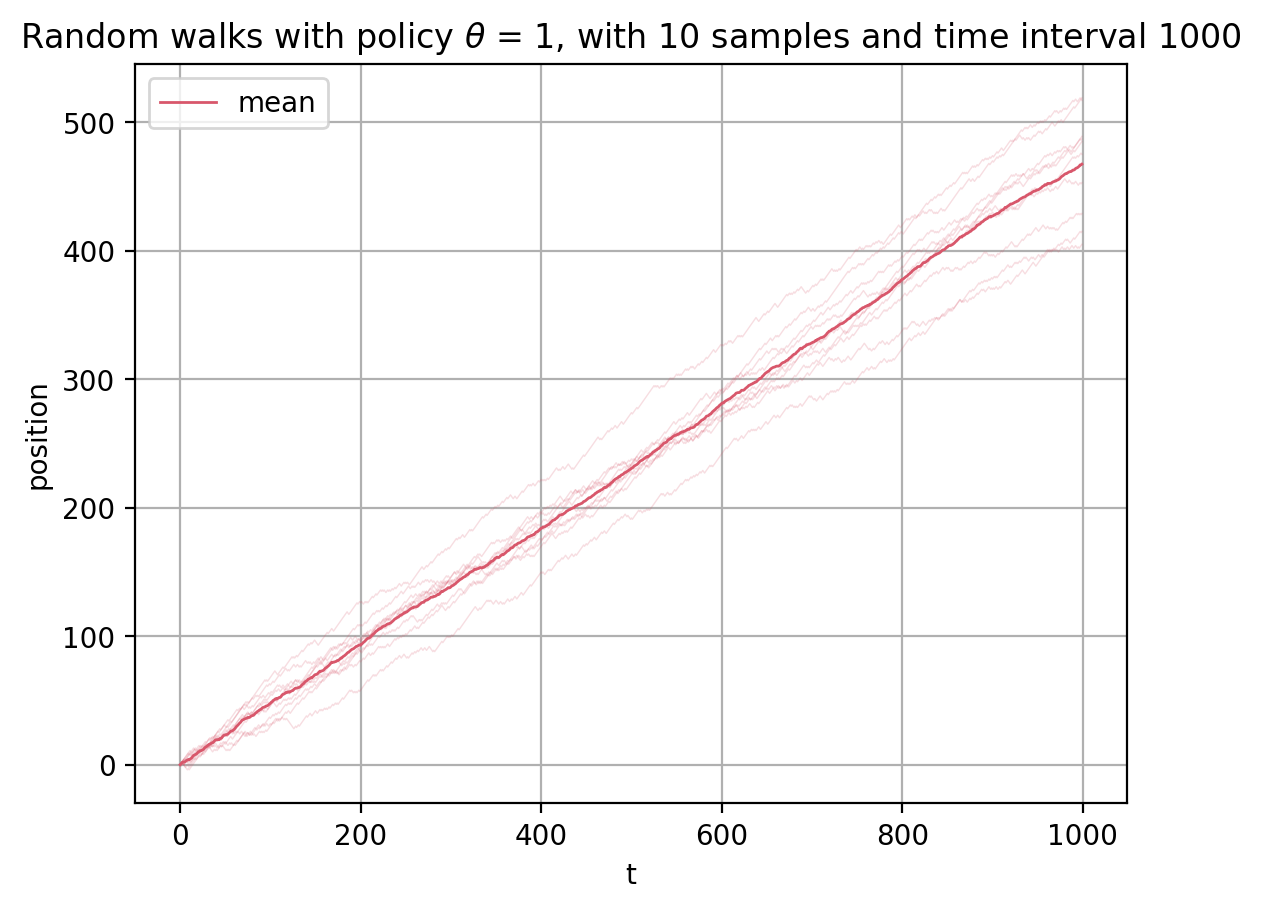

In [ ]:
# @title
#Let's plot our trajectories above

def plot_trajectories(theta,T,n):
  gamerun, rewards, N_plus, trajectories = policybatch(T,theta,n)
  colors = plt.cm.plasma(np.linspace(0, 1, 10))  # n = number of indices

  for j in range(n):
      plt.plot(gamerun, trajectories[j, :], alpha=0.2,color=colors[5],linewidth=0.5)

  plt.plot(gamerun, np.mean(trajectories, axis=0), color=colors[5], linewidth=1, label='mean',alpha=1) #include mean trajectory. this is cool, it does a rolling average!
  plt.legend()

  plt.xlabel("t")
  plt.ylabel("position")
  plt.grid(True)
  plt.title(rf"Random walks with policy $\theta$ = {theta}, with {n} samples and time interval {T}") #r-string allows latex. f-string allows me to quote variable values
  plt.show()



T=1000
theta = 1 #initialise near pi/2, this is an uncertain policy
n=10
plot_trajectories(theta,T,n)

In [ ]:
# @title
# Now we need to build our updates.

def AvgVar(n,N_plus,T,theta):
      return 1/n * np.sum((N_plus - T*walkpolicy(theta, 1))**2) #this approximates E[(N_+ - <N_+>)^2]

def traingogogo(n,theta_init, num_epochs,T,eta):
  """
  parameters:
  n: int - the number of trajectories sampled at a given theta in the training ie the stochastic batch size
  theta_init: float - the starting value of theta in parameter space
  num_epochs: int - obvious
  T: int - gamerun time.
  eta: float - step size during gradient descenet

  return:
  thetalist: np.darray shape (num_epochs,) - the list of thetas as we train. each time step is eta, so total time is eta*num_epochs.
  """
  thetalist=np.zeros(num_epochs)
  thetalist[0] = theta_init
  theta = theta_init
  for i in range(1,num_epochs): #since the 0th entry of thetalist is filled in
    N_plus = policybatch(T,theta,n)[2] #there are a number of returned stuff from this function so just use output index 2 for n plus.
    theta+= 2*eta*AvgVar(n,N_plus,T,theta)
    #theta+= 2*eta*T*walkpolicy(theta,1)*walkpolicy(theta,-1) #this commented out bit is the correct delta theta without stochastics
    thetalist[i] = theta

  return thetalist


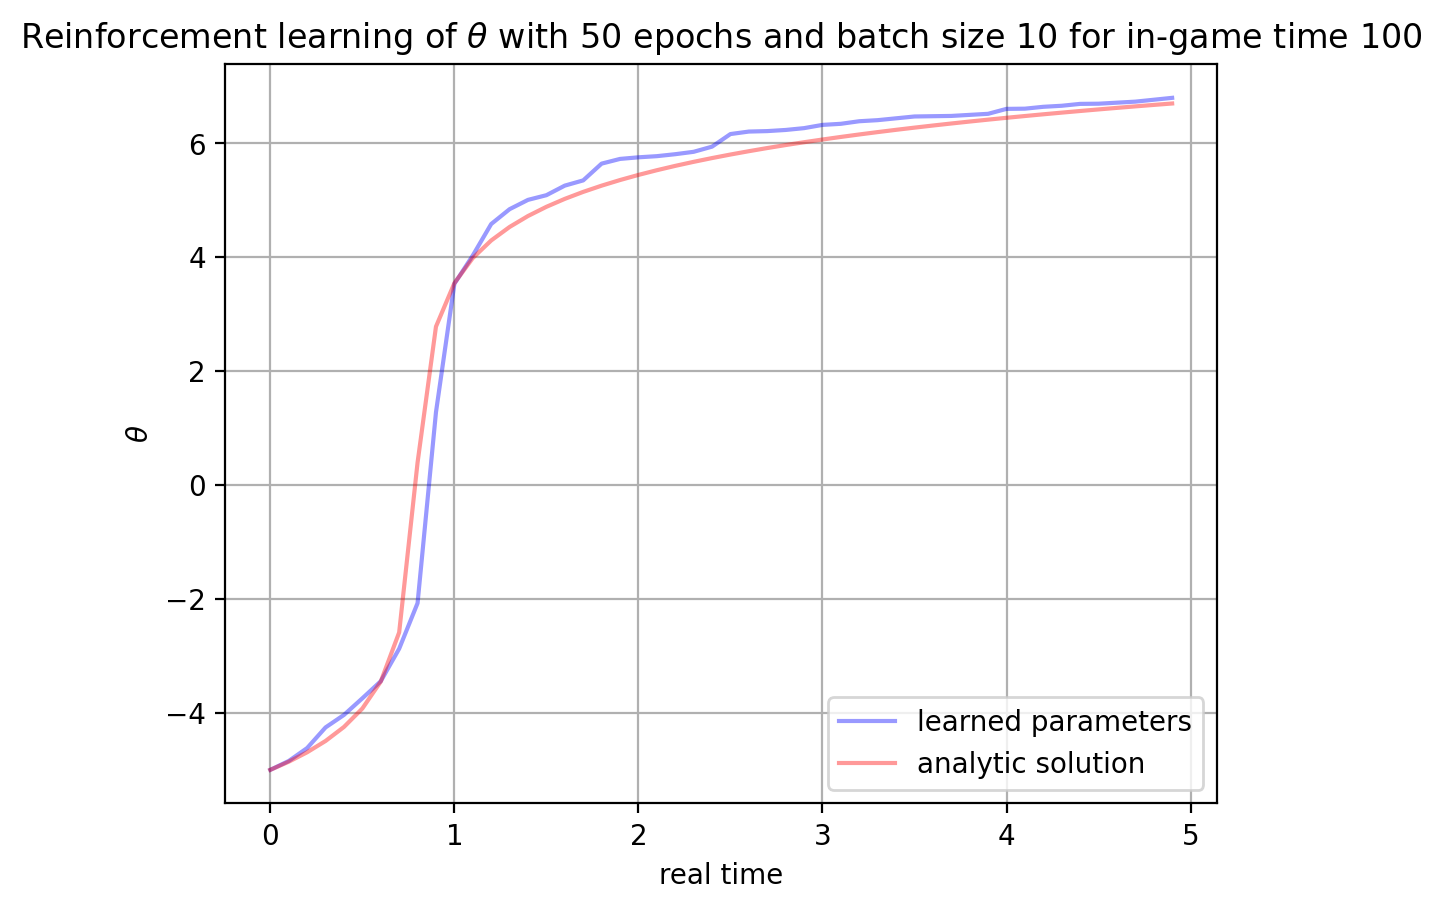

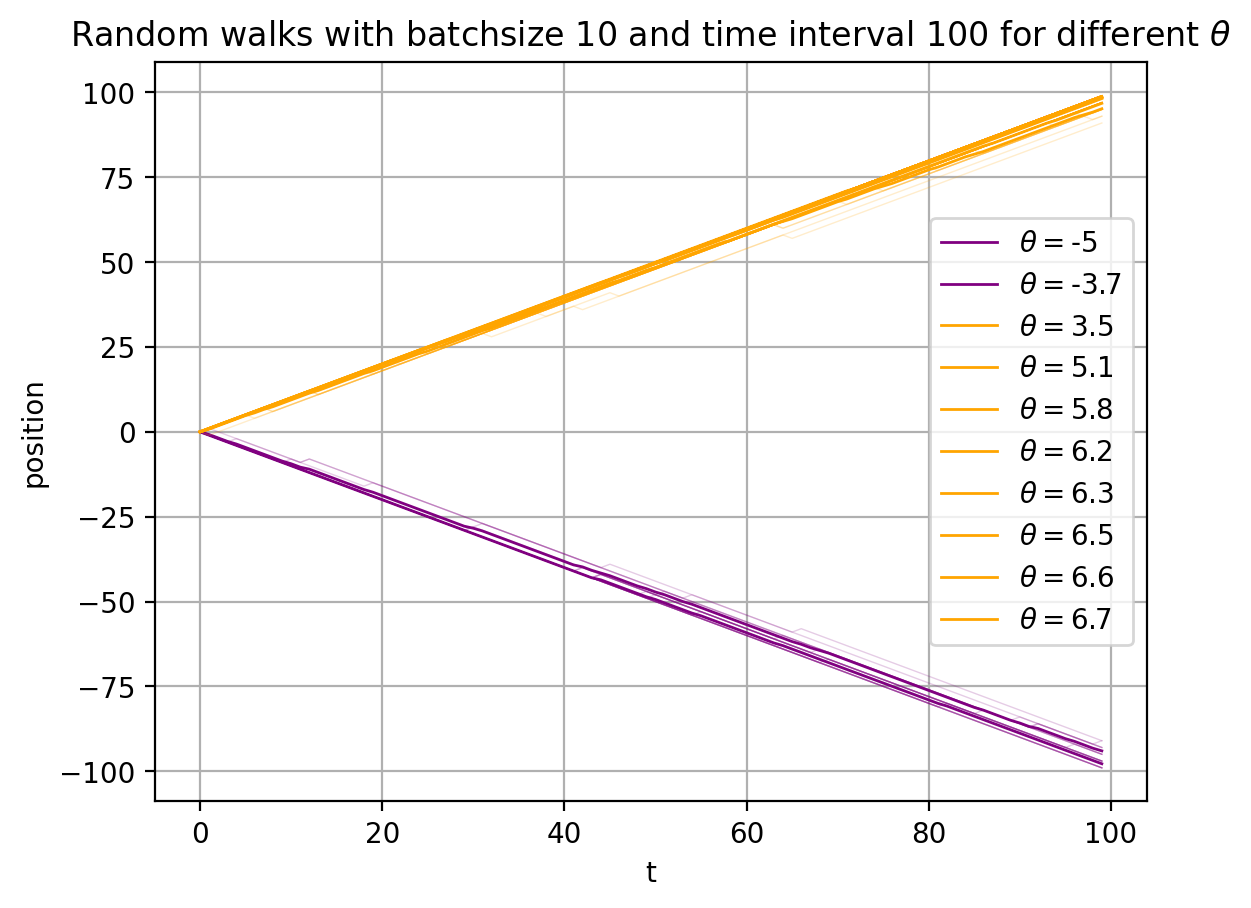

In [ ]:
# @title
#to visualise the growth, view num_epochs at total real time and eta as delta time. we compare training to correct solution!


#training data
n=10
theta_init=-5
num_epochs=50
T=100
eta=0.1
thetalist = traingogogo(n,theta_init, num_epochs,T,eta)
realtime = np.linspace(0, (num_epochs-1)*eta,num_epochs)

#solution data
sol_vals = [brentq(analytictheta, -100, 100, args=(omega,T,theta_init)) for omega in realtime]
realtime = np.linspace(0, (num_epochs-1)*eta,num_epochs) #fiddled with this so that delta omegas are correct
plt.plot(realtime, thetalist, alpha=0.4,color='blue',label='learned parameters')
plt.plot(realtime, sol_vals, alpha=0.4,color='red',label = 'analytic solution')

plt.legend()
plt.xlabel("real time")
plt.ylabel(rf"$\theta$")
plt.grid(True)
plt.title(rf"Reinforcement learning of $\theta$ with {num_epochs} epochs and batchsize {n} for in-game time {T}") #r-string allows latex. f-string allows me to quote variable values
plt.show()

#to visualise the learning, i want to plot the trajectories x(t) in-game for each theta and see how the spread lessens and lessens. we have an x vs t plot with many lines. a given theta determines a colour, and we plot an ensemble of trajectories at that theta, with a thick line for its average.

#we specify batch_size, thetalist, T
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

num_thetas = 10
sampled_thetas = thetalist[::len(thetalist)//num_thetas] #just plucks num_theta (roughly) many evenly spaced values out of thetalist for me to plot
gamerun = np.linspace(0, T-1,T)

#building my colour stuff to classify datasets
cmap = LinearSegmentedColormap.from_list("custom", ["purple", "teal", "orange"])
norm = TwoSlopeNorm(vcenter=0, vmin=-1, vmax=1)


for thetaval in sampled_thetas:
  trajs = policybatch(T,thetaval,n)[3]
  for j in range(n):
      plt.plot(gamerun, trajs[j, :], alpha=0.2,color = cmap(norm(thetaval)),linewidth=0.5)

  plt.plot(gamerun, np.mean(trajs, axis=0), color = cmap(norm(thetaval)), linewidth=1, label=rf'$\theta=${thetaval:.2g}',alpha=1) #include mean trajectory. this is cool, it does a rolling average!

plt.legend()

plt.xlabel("t")
plt.ylabel("position")
plt.grid(True)
plt.title(rf"Random walks with batchsize {n} and in-game time {T} for different $\theta$") #r-string allows latex. f-string allows me to quote variable values
plt.show()

So that concludes the warm-up. Let's summarise what we have so far before we develop RL for my market model.

NOTE: FIRST MAKE A THINKBOT THAT NEVER INVESTS BUT COLLECTS MORE AND MORE DATA AND TRIES OUT SIMULATED STRATEGIES TO SEE WHAT HAPPENS, PLOT THE VARIANCE OF ITS POLICY AS WE UPDATE IT OVER TIME. SHOULD SEE IT GET MORE CONFIDENT (LESS SPREAD) OVER TIME ABOUT WHAT IT SHOULD DO I.E. THE POLICY MEAN SHOULD CONVERGE AND THE VARIANCE SHOULD GO TO ZERO AS TIME GOES TO INFINITY.

THEN: BUILD AN INVESTORBOT THAT ACTS AS THINKBOT UNTIL VARIANCE GOES BELOW SOME THRESHOLD (CONFIDENT ENOUGH) AND START ACTUALLY INVESTING!!!

In [ ]:
# @title
class Network:
    def __init__(self, layers, activations = None, weights = None, biases = None):
        self.nLayers = len(layers)
        self.nNeurons = layers

        # Initialise activation function structures for each layer
        if activations == None:
            self.activations = ["sigmoid"]*(self.nLayers-1)
        elif type(activations) == list:
            if len(activations) != self.nLayers - 1:
                raise Exception("The length of your list of activations must match the number of layers!")
            self.activations = activations
        elif type(activations) == str:
            self.activations = [activations]*(self.nLayers-1)

        # Determine correct shapes for weights and biases
        self.weightsShape = [(self.nNeurons[j+1], self.nNeurons[j]) for j in range(self.nLayers - 1)]
        self.biasesShape = [(self.nNeurons[j+1],1) for j in range(self.nLayers - 1)]

        # Initialise weights
        if weights == None:
            self.weights = [np.random.uniform(low = -1.,
                                              high = 1.,
                                              size = [self.nNeurons[j+1],self.nNeurons[j]])
                            for j in range(self.nLayers-1)]
        elif [_wMat.shape for _wMat in weights] == self.weightsShape:
            self.weights = weights
        else:
            raise Exception("I hate your weights!")

        # Initialise biases
        if biases == None:
            self.biases = [np.random.uniform(low = -1.,
                                              high = 1.,
                                              size = [self.nNeurons[j+1],1])
                            for j in range(self.nLayers-1)]
        elif [_bVec.shape for _bVec in biases] == self.biasesShape:
            self.biases = biases
        else:
            raise Exception("I hate your biases!")

        self.backpropagating = True

    def __repr__(self):
      return "Mind your own business"

    def ActivationFunction(self, yInput, label = None, Q_return_df = False):
        if label == None:
            label = "sigmoid"
        if label == "sigmoid":
            if Q_return_df == True:
                return 1/(1+np.exp(-yInput)), np.exp(-yInput)/(1+np.exp(-yInput))**2
            else:
                return 1/(1+np.exp(-yInput))
        if label == "step":
            return (yInput >= 0)
        if label == "reLU":
            if Q_return_df == True:
                return (yInput > 0) * yInput, (yInput>0)
            else:
                return (yInput >= 0) * yInput

    def ForwardStep(self, layerIndex, yInput):
        yOut = np.dot(self.weights[layerIndex - 1],yInput) + self.biases[layerIndex - 1]
        if self.backpropagating == True:
            zOut, dfOut = self.ActivationFunction(yOut, self.activations[layerIndex - 1], Q_return_df = True)
            return zOut, dfOut
        else:
            zOut = self.ActivationFunction(yOut, self.activations[layerIndex - 1])
            return zOut

    def NetworkPass(self, yInput):
        yj = yInput
        if self.backpropagating == True:
            self.yi_layers[0] = yj
        for layerIndex in range(self.nLayers - 1):
            if self.backpropagating == True:
                yj, dfj = self.ForwardStep(layerIndex + 1, yj)
                self.yi_layers[layerIndex + 1] = yj
                self.dfi_layers[layerIndex] = dfj
            else:
                yj = self.ForwardStep(layerIndex+1,yj)
        return yj

    def BackPropagate(self, yBatch, yTarget): #unique to RL!
        self.backpropagating = True

        batchSize = yBatch.shape[-1]

        self.yi_layers = [np.zeros([batchSize, self.nNeurons[j]])
                          for j in range(self.nLayers)]
        self.dfi_layers = [np.zeros([batchSize, self.nNeurons[j+1]])
                           for j in range(self.nLayers-1)]
        self.dwi_layers = [np.zeros([self.nNeurons[j+1], self.nNeurons[j]])
                            for j in range(self.nLayers-1)]
        self.dbi_layers = [np.zeros([self.nNeurons[j+1],1])
                            for j in range(self.nLayers-1)]

        yOut = self.NetworkPass(yBatch)
        delta = (self.yi_layers[-1] - yTarget)*self.dfi_layers[-1]
        self.dwi_layers[-1] = np.dot(delta,np.transpose(self.yi_layers[-2]))/batchSize
        self.dbi_layers[-1] = delta.sum(0)/batchSize
        for j in range(self.nLayers - 2):
            delta = np.dot(np.transpose(self.weights[-1-j]), delta)*self.dfi_layers[-2-j]
            self.dwi_layers[-2-j] = np.dot(delta, np.transpose(self.yi_layers[-3-j]))/batchSize
            self.dbi_layers = delta.sum(0)/batchSize
        return yOut

    def UpdateWeights(self, eta = 0.1):
        for j in range(self.nLayers-1):
            self.weights[j] -= eta*self.dwi_layers[j]
            self.biases[j] -= eta*self.dbi_layers[j]

    def TrainNet(self, yBatch, yTarget, eta = 0.0001): # one full training batch
        batchSize = yBatch.shape[-1]
        yOutput = self.BackPropagate(yBatch, yTarget)
        self.UpdateWeights(eta)
        cost=((yTarget-yOutput)**2).sum()/batchSize
        return(cost)